# Iraq vs Norway match prediction (2026-06-16)

Predicts today's World Cup group match with the project's two-model core:

* **Logistic regression** — clean W/D/L probabilities
* **Poisson** — football specific scoreline probabilities (expected goals to scoreline grid).

## 1. Setup

In [10]:
import sys
import pathlib

import numpy as np
import pandas as pd

# Make the project importable whether this runs from notebooks/ or the project root.
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

from scipy.stats import poisson

from src.data_collection import build_inputs
from src.preprocessing import load_data as L
from src.features import build_features as F
from src.models import logistic_model as LM
from src.models import poisson_model as P
from src.models.logistic_model import proba_frame
from src.utils.config import FIXTURES, RESULT_CLASSES

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 2. Build dataset

The Iraq vs Norway fixture is `FIXTURES[0]`.

In [11]:
build_inputs.build_all(force=False)

matches = L.load_matches()
flashscore = L.repair_flashscore(L.load_flashscore(), matches)
fifa = L.load_fifa()
elo = L.load_elo()

persp_feat, model_dataset, all_team_dataset, fixture_dataset = F.engineer(
    matches, elo, fifa, flashscore, FIXTURES)

print("fixtures available:", sorted(fixture_dataset["match_id"].unique()))

12:48:04 | INFO    | src.data_collection.build_inputs | matches.csv + elo_ratings.csv present - skipping eloratings
12:48:04 | INFO    | src.data_collection.build_inputs | fifa_rankings.csv present - skipping
12:48:04 | INFO    | src.data_collection.build_inputs | flashscore_stats.csv present - skipping
12:48:04 | INFO    | src.preprocessing.load_data | loaded 4638 matches (2020-12-04 -> 2026-06-13)
12:48:04 | INFO    | src.preprocessing.load_data | loaded 498 Flashscore team-match rows (106 teams)
12:48:04 | INFO    | src.preprocessing.load_data | Flashscore repair: checked 232 paired matches, swapped 45, nulled 0 unfixable single rows
12:48:04 | INFO    | src.preprocessing.load_data | team-perspective rows: 9276 (4638 matches x 2 sides)
12:48:04 | INFO    | src.preprocessing.load_data | attached Flashscore stats (xg coverage: 175/9276 perspective rows)
12:48:18 | INFO    | src.features.build_features | model dataset: 285 focus rows | 9284 all-team rows | 6 fixture rows
fixtures avail

## 3. Fit the two core models

* **Logistic** is trained on the broader all-team dataset (more rows → better-calibrated
  probabilities; this is what the pipeline uses).
* **Poisson** attack/defence strengths are computed from team-perspective goal rates.

In [12]:
fitted = LM.fit_final(model_dataset, train_override=all_team_dataset)
model, feats = fitted["logistic"]

mu, strengths = P.compute_strengths(persp_feat)
print(f"logistic trained on {len(all_team_dataset):,} rows | "
      f"Poisson league avg = {mu:.2f} goals/team/match")

12:48:18 | INFO    | src.models.logistic_model | fitted logistic on 9284 rows (half-life=1095 d)
12:48:18 | INFO    | src.models.poisson_model | Poisson strengths: 201 teams, league avg = 1.31 goals/team/match
logistic trained on 9,284 rows | Poisson league avg = 1.31 goals/team/match


## 4. Predict match

Iraq is the nominal home side (listed first), but the venue is neutral, so
`is_home = 0` for both. We score the fixture from Norway's perspective; Iraq's
win probability is simply Norway's loss probability.

In [13]:
TEAM, OPP, DATE = "Norway", "Iraq", "2026-06-16"
MID = f"FIX_{TEAM}_{OPP}_{DATE}"

row = fixture_dataset[(fixture_dataset["match_id"] == MID) & (fixture_dataset["team"] == TEAM)]
assert len(row) == 1, f"expected one Norway row for {MID}, got {len(row)}"

# Logistic W/D/L (Norway's perspective).
log_p = proba_frame(model, row[feats]).iloc[0]

# Poisson W/D/L + expected goals (neutral venue -> is_home=0).
pois = P.predict(strengths, mu, TEAM, OPP, is_home=0, is_neutral=1)

# Ensemble = mean(logistic, Poisson), same as the pipeline.
ens = {c: (float(log_p[c]) + float(pois[c])) / 2 for c in RESULT_CLASSES}

table = pd.DataFrame({
    "Norway win": [log_p["win"], pois["win"], ens["win"]],
    "Draw":       [log_p["draw"], pois["draw"], ens["draw"]],
    "Iraq win":   [log_p["loss"], pois["loss"], ens["loss"]],
}, index=["logistic", "poisson", "ensemble"])
(table * 100).round(1)

,Norway win,Draw,Iraq win
logistic,77.7,17.6,4.8
poisson,53.5,24.7,21.8
ensemble,65.6,21.1,13.3


## 5. Predicted scoreline (Poisson)

The two expected-goal rates (λ) define an independent Poisson grid over scorelines.
Below, we have each side's expected goals, the probability of every scoreline 0–5 (in %,
Norway down the rows, Iraq across the columns), and the most likely results.

In [14]:
lam_nor, lam_irq = pois["lam_team"], pois["lam_opp"]
print(f"Expected goals  ->  Norway {lam_nor:.2f}   |   Iraq {lam_irq:.2f}")

MAXG = 5
a = poisson.pmf(np.arange(MAXG + 1), lam_nor)
b = poisson.pmf(np.arange(MAXG + 1), lam_irq)
grid = np.outer(a, b)  # rows = Norway goals, cols = Iraq goals

grid_df = pd.DataFrame(
    grid,
    index=pd.Index(range(MAXG + 1), name="Norway"),
    columns=pd.Index(range(MAXG + 1), name="Iraq"),
)
# Cell = P(exact scoreline), %. (0-5 view; tail beyond 5 goals omitted, so rows
# need not sum to exactly 100.)
(grid_df * 100).round(1)

Expected goals  ->  Norway 1.63   |   Iraq 0.94


Iraq,0,1,2,3,4,5
Norway,,,,,,
0,7.6,7.2,3.4,1.1,0.3,0.0
1,12.4,11.7,5.5,1.7,0.4,0.1
2,10.1,9.6,4.5,1.4,0.3,0.1
3,5.5,5.2,2.5,0.8,0.2,0.0
4,2.3,2.1,1.0,0.3,0.1,0.0
5,0.7,0.7,0.3,0.1,0.0,0.0


In [15]:
# Top-5 most likely scorelines (Norway-Iraq).
flat = [(f"{i}-{j}", grid[i, j]) for i in range(MAXG + 1) for j in range(MAXG + 1)]
top5 = (pd.DataFrame(flat, columns=["Norway-Iraq", "probability"])
        .sort_values("probability", ascending=False)
        .head(5)
        .reset_index(drop=True))
top5["probability"] = (top5["probability"] * 100).round(1)
top5

,Norway-Iraq,probability
0,1-0,12.4
1,1-1,11.7
2,2-0,10.1
3,2-1,9.6
4,0-0,7.6


## 6. Verdict

In [16]:
i, j = pois["score"]
verdict = {"win": "Norway win", "draw": "Draw", "loss": "Iraq win"}[max(ens, key=ens.get)]

print(f"Iraq vs Norway  -  {DATE}  (neutral venue)")
print("-" * 48)
print(f"  Norway win   {ens['win']*100:4.0f}%")
print(f"  Draw         {ens['draw']*100:4.0f}%")
print(f"  Iraq win     {ens['loss']*100:4.0f}%")
print(f"  -> consensus: {verdict}")
print(f"  Most likely scoreline: Norway {i}-{j} Iraq")
print(f"  Expected goals: Norway {lam_nor:.2f} | Iraq {lam_irq:.2f}")

Iraq vs Norway  -  2026-06-16  (neutral venue)
------------------------------------------------
  Norway win     66%
  Draw           21%
  Iraq win       13%
  -> consensus: Norway win
  Most likely scoreline: Norway 1-0 Iraq
  Expected goals: Norway 1.63 | Iraq 0.94


## 7. Feature importance (logistic model)

Because the logistic model standardizes its inputs, the **magnitude of each
coefficient is a fair importance measure** and its sign gives direction. The chart
shows the standardized coefficients for the *Norway-win* class — bar length = how
strongly a feature drives P(Norway win), green = pushes toward a Norway win, red =
away. The table lists the full per-class coefficients ranked by overall importance
(mean |coef| across win/draw/loss).

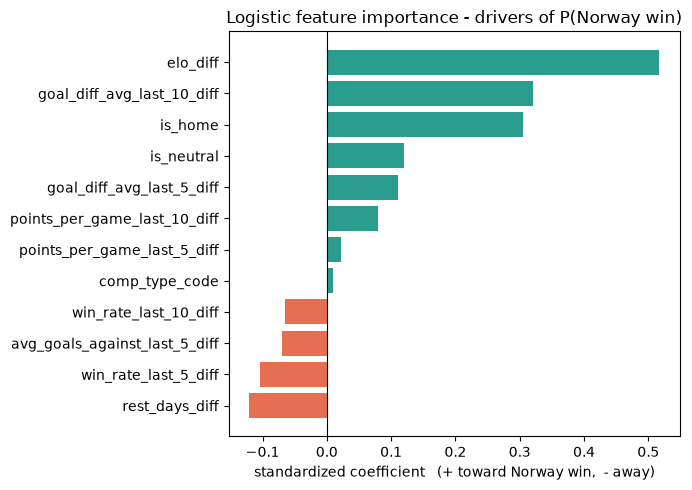

,draw,loss,win,importance
elo_diff,-0.000,-0.517,0.517,0.345
goal_diff_avg_last_10_diff,-0.000,-0.320,0.320,0.213
is_home,-0.000,-0.305,0.305,0.203
is_neutral,0.064,-0.185,0.121,0.123
rest_days_diff,0.000,0.121,-0.121,0.080
goal_diff_avg_last_5_diff,0.000,-0.111,0.111,0.074
win_rate_last_5_diff,-0.001,0.105,-0.104,0.070
points_per_game_last_10_diff,-0.001,-0.079,0.080,0.053
avg_goals_against_last_5_diff,0.000,0.070,-0.070,0.047
win_rate_last_10_diff,0.001,0.065,-0.065,0.044


In [17]:
import matplotlib.pyplot as plt

# The logistic pipeline standardizes its inputs, so coefficient size = importance.
clf = model.named_steps["clf"]
classes = list(clf.classes_)                        # ['draw', 'loss', 'win']
coef_df = pd.DataFrame(clf.coef_.T, index=feats, columns=classes)
coef_df["importance"] = coef_df[classes].abs().mean(axis=1)

# Standardized coefficients for the Norway-win class:
# bar length = importance, sign = direction.
win_coef = coef_df["win"].sort_values()
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in win_coef.values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(win_coef.index, win_coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient   (+ toward Norway win,  - away)")
ax.set_title("Logistic feature importance - drivers of P(Norway win)")
plt.tight_layout()
plt.show()

# Full per-class coefficients, ranked by overall importance (mean |coef|).
coef_df.sort_values("importance", ascending=False).round(3)

---

**How to read this.** Probabilities are directional, not certainties. Consistent
findings for this project: **Elo dominates** the signal, **draws are hard** to call
as the single most likely outcome (a known property of 3-class football models),
and the advanced Flashscore stats are sparse / mostly imputed for a June 2026 match,
so they add little here. The sample is small — treat the numbers as a reasoned lean,
not a guarantee.